# Semantic Search — Data Exploration (MS MARCO)

## Цель

На данном этапе проводится исследовательский анализ (Exploratory Data Analysis, EDA) датасета **MS MARCO**, который будет использоваться для построения системы семантического поиска.

Основная задача исследования — изучить структуру данных, определить необходимые признаки для дальнейшей обработки и сформировать требования к этапу preprocessing.

---

## Цели исследования

В ходе работы необходимо:

- загрузить датасет из Hugging Face;
- изучить структуру выборок;
- определить количество объектов;
- исследовать состав каждого поля;
- оценить качество данных;
- выявить наличие пропусков;
- получить статистические характеристики текстов;
- определить поля, которые будут использоваться в модели поиска.

---

## Ожидаемый результат

После завершения исследования должны быть получены ответы на следующие вопросы:

- Какие поля действительно необходимы?
- Какие данные можно исключить?
- Какие операции потребуется выполнить на этапе предобработки текста?

## Импорт библиотек

На данном этапе импортируются библиотеки, необходимые для загрузки датасета, анализа структуры данных и вычисления статистических характеристик.

In [32]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

## Загрузка датасета

Датасет загружается напрямую из репозитория Hugging Face.

Для исследования используется коллекция **MS MARCO**, содержащая поисковые запросы пользователей, набор релевантных документов и дополнительные служебные поля.

In [2]:
dataset = load_dataset("microsoft/ms_marco", "v1.1", split="train")

## Общая информация о датасете

На данном этапе анализируется общая структура датасета:

- количество выборок;
- названия выборок;
- число объектов в каждой выборке.

In [3]:
dataset

Dataset({
    features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
    num_rows: 82326
})

## Структура данных

На предыдущем этапе было установлено, что датасет представляет собой единую коллекцию из **82 326** записей и не содержит отдельных выборок (`train`, `validation`, `test`).

Каждая запись соответствует одному поисковому запросу пользователя и содержит связанную с ним информацию.

На данном этапе необходимо:

- определить состав полей;
- изучить тип данных каждого поля;
- исследовать вложенные структуры;
- подготовить информацию для последующей обработки.

In [11]:
dataset.features

{'answers': List(Value('string')),
 'passages': {'is_selected': List(Value('int32')),
  'passage_text': List(Value('string')),
  'url': List(Value('string'))},
 'query': Value('string'),
 'query_id': Value('int32'),
 'query_type': Value('string'),
 'wellFormedAnswers': List(Value('string'))}

## Исследование полей датасета

Каждая запись содержит несколько признаков, описывающих поисковый запрос и связанные с ним документы.

Далее последовательно исследуется каждое поле датасета с целью определить его структуру и необходимость использования в дальнейшем.

### Поле `query`

Поле `query` содержит исходный поисковый запрос пользователя.

Данное поле является основным входом для системы семантического поиска, поэтому необходимо оценить его содержимое и структуру.

In [12]:
dataset[0]["query"]

'what is rba'

### Поле `passages`

Поле `passages` содержит список документов, связанных с поисковым запросом.

Каждый документ представляет собой вложенную структуру, содержащую:

- идентификатор документа;
- текст документа;
- признак релевантности.

Именно это поле является основным источником данных для построения поискового индекса.

In [13]:
dataset[0]["passages"]

{'is_selected': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
 'passage_text': ["Since 2007, the RBA's outstanding reputation has been affected by the 'Securency' or NPA scandal. These RBA subsidiaries were involved in bribing overseas officials so that Australia might win lucrative note-printing contracts. The assets of the bank include the gold and foreign exchange reserves of Australia, which is estimated to have a net worth of A$101 billion. Nearly 94% of the RBA's employees work at its headquarters in Sydney, New South Wales and at the Business Resumption Site.",
  "The Reserve Bank of Australia (RBA) came into being on 14 January 1960 as Australia 's central bank and banknote issuing authority, when the Reserve Bank Act 1959 removed the central banking functions from the Commonwealth Bank. The assets of the bank include the gold and foreign exchange reserves of Australia, which is estimated to have a net worth of A$101 billion. Nearly 94% of the RBA's employees work at its headquarters in Sydn

### Поле `answers`

Поле `answers` содержит эталонные ответы на поисковый запрос.

Предполагается, что данное поле используется преимущественно при обучении и оценке моделей Question Answering.

Необходимо определить полноту заполнения данного поля и его потенциальную ценность для текущего проекта.

In [14]:
dataset[0]["answers"]

['Results-Based Accountability is a disciplined way of thinking and taking action that communities can use to improve the lives of children, youth, families, adults and the community as a whole.']

### Поле `query_type`

Поле `query_type` содержит информацию о категории поискового запроса.

В рамках проекта необходимо определить, используется ли данный признак при построении поисковой системы или может быть исключён.

In [15]:
dataset[0]["query_type"]

'description'

### Поле `wellFormedAnswers`

Поле `wellFormedAnswers` содержит ответы, сформулированные в более естественной форме.

Необходимо оценить частоту заполнения данного поля и определить целесообразность его дальнейшего использования.

In [16]:
dataset[0]["wellFormedAnswers"]

[]

### Поле `query_id`

Поле `query_id` содержит уникальный идентификатор поискового запроса.

Данный идентификатор может использоваться для сопоставления объектов, однако не несёт смысловой информации для алгоритмов поиска.

In [17]:
dataset[0]["query_id"]

19699

## Анализ качества данных

Перед построением моделей необходимо оценить качество исходного датасета.

На данном этапе будут проверены:

- наличие пустых поисковых запросов;
- наличие пустых документов;
- отсутствие ответов;
- заполненность дополнительных полей.

Полученные результаты позволят определить необходимость очистки данных на этапе preprocessing.

### Проверка пустых запросов

In [18]:
empty_queries = sum(
    1 for sample in dataset
    if not sample["query"].strip()
)

print(f"Пустых запросов: {empty_queries}")

Пустых запросов: 0


### Проверка пустых списков документов

In [20]:
empty_passages = sum(
    1 for sample in dataset
    if len(sample["passages"]["passage_text"]) == 0
)

print(f"Записей без документов: {empty_passages}")

Записей без документов: 0


### Проверка пустых ответов

In [22]:
empty_answers = sum(
    1 for sample in dataset
    if len(sample["answers"]) == 0
)

print(f"Записей без ответов: {empty_answers}")

Записей без ответов: 2183


### Проверка поля wellFormedAnswers

In [23]:
empty_wellformed = sum(
    1 for sample in dataset
    if len(sample["wellFormedAnswers"]) == 0
)

print(f"Пустых wellFormedAnswers: {empty_wellformed}")

Пустых wellFormedAnswers: 82326


## Статистический анализ

### Длина запросов

In [24]:
query_lengths = [
    len(sample["query"].split())
    for sample in dataset
]

print(f"Минимум: {min(query_lengths)}")
print(f"Максимум: {max(query_lengths)}")
print(f"Среднее: {np.mean(query_lengths):.2f}")
print(f"Медиана: {np.median(query_lengths):.2f}")

Минимум: 1
Максимум: 26
Среднее: 6.05
Медиана: 6.00


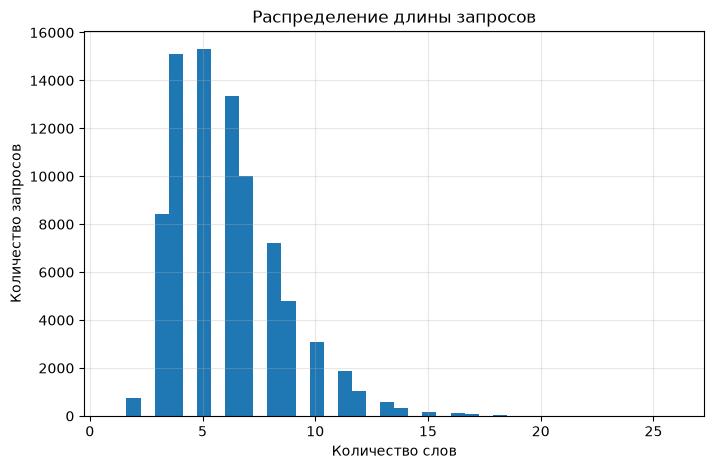

In [33]:
query_lengths = [len(sample["query"].split()) for sample in dataset]

plt.figure(figsize=(8, 5))
plt.hist(query_lengths, bins=40)
plt.title("Распределение длины запросов")
plt.xlabel("Количество слов")
plt.ylabel("Количество запросов")
plt.grid(alpha=0.3)

plt.show()

### Длина документов

In [25]:
passage_lengths = []

for sample in dataset:
    for passage in sample["passages"]["passage_text"]:
        passage_lengths.append(len(passage.split()))

print(f"Минимум: {min(passage_lengths)}")
print(f"Максимум: {max(passage_lengths)}")
print(f"Среднее: {np.mean(passage_lengths):.2f}")
print(f"Медиана: {np.median(passage_lengths):.2f}")

Минимум: 3
Максимум: 231
Среднее: 70.89
Медиана: 71.00


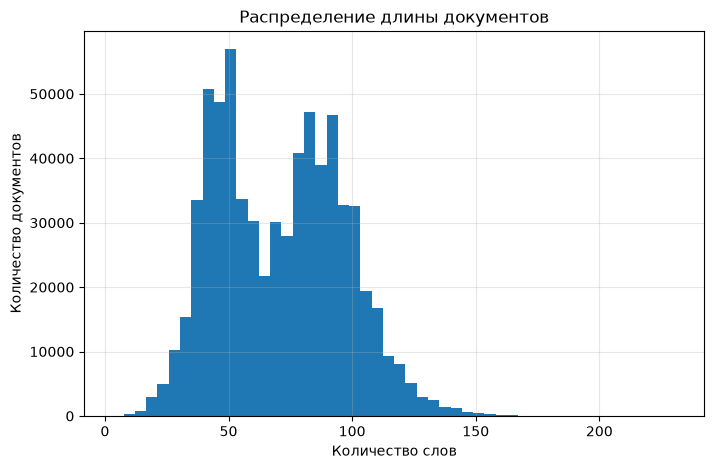

In [34]:
passage_lengths = []

for sample in dataset:
    for passage in sample["passages"]["passage_text"]:
        passage_lengths.append(len(passage.split()))

plt.figure(figsize=(8, 5))
plt.hist(passage_lengths, bins=50)
plt.title("Распределение длины документов")
plt.xlabel("Количество слов")
plt.ylabel("Количество документов")
plt.grid(alpha=0.3)

plt.show()

### Количество документов на запрос

In [26]:
passages_per_query = [
    len(sample["passages"]["passage_text"])
    for sample in dataset
]

print(f"Минимум: {min(passages_per_query)}")
print(f"Максимум: {max(passages_per_query)}")
print(f"Среднее: {np.mean(passages_per_query):.2f}")
print(f"Медиана: {np.median(passages_per_query):.2f}")

Минимум: 1
Максимум: 12
Среднее: 8.21
Медиана: 9.00


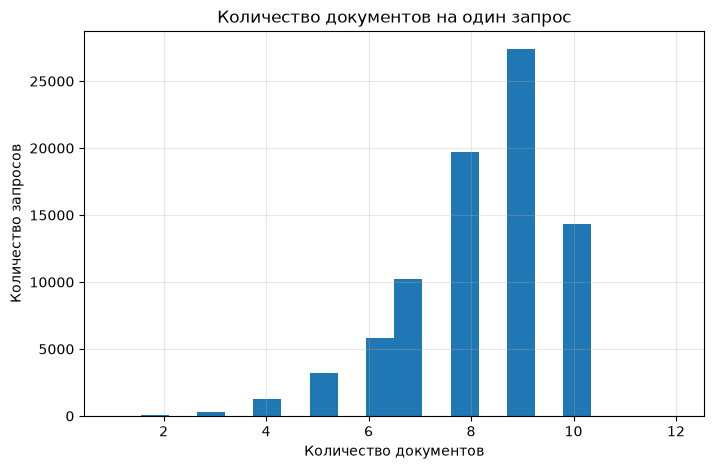

In [35]:
num_passages = [
    len(sample["passages"]["passage_text"])
    for sample in dataset
]

plt.figure(figsize=(8, 5))
plt.hist(num_passages, bins=20)
plt.title("Количество документов на один запрос")
plt.xlabel("Количество документов")
plt.ylabel("Количество запросов")
plt.grid(alpha=0.3)

plt.show()

### Сводная статистика

In [27]:
stats = pd.DataFrame({
    "Длина запроса": query_lengths,
    "Количество документов": passages_per_query
})

stats.describe()

,Длина запроса,Количество документов
count,82326.000000,82326.000000
mean,6.048381,8.213602
std,2.392057,1.450689
min,1.000000,1.000000
25%,4.000000,7.000000
50%,6.000000,9.000000
75%,7.000000,9.000000
max,26.000000,12.000000


## Просмотр примеров

In [28]:
pprint(dataset[0])

{'answers': ['Results-Based Accountability is a disciplined way of thinking '
             'and taking action that communities can use to improve the lives '
             'of children, youth, families, adults and the community as a '
             'whole.'],
 'passages': {'is_selected': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
              'passage_text': ["Since 2007, the RBA's outstanding reputation "
                               "has been affected by the 'Securency' or NPA "
                               'scandal. These RBA subsidiaries were involved '
                               'in bribing overseas officials so that '
                               'Australia might win lucrative note-printing '
                               'contracts. The assets of the bank include the '
                               'gold and foreign exchange reserves of '
                               'Australia, which is estimated to have a net '
                               'worth of A$101 billion. Nearly 9

In [29]:
pprint(dataset[1])

{'answers': ['Yes'],
 'passages': {'is_selected': [0, 1, 0, 0, 0, 0, 0],
              'passage_text': ['In his younger years, Ronald Reagan was a '
                               'member of the Democratic Party and campaigned '
                               'for Democratic candidates; however, his views '
                               'grew more conservative over time, and in the '
                               'early 1960s he officially became a Republican. '
                               'In November 1984, Ronald Reagan was reelected '
                               'in a landslide, defeating Walter Mondale and '
                               'his running mate Geraldine Ferraro (1935-), '
                               'the first female vice-presidential candidate '
                               'from a major U.S. political party.',
                               'From Wikipedia, the free encyclopedia. A '
                               'Reagan Democrat is a traditionally Demo

In [30]:
pprint(dataset[2])

{'answers': ['20-25 minutes'],
 'passages': {'is_selected': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
              'passage_text': ['Sydney, New South Wales, Australia is located '
                               'in a coastal basin bordered by the Pacific '
                               'Ocean to the east, the Blue Mountains to the '
                               'west, the Hawkesbury River to the north and '
                               'the Woronora Plateau to the south. The Sydney '
                               'Statistical Division, used for census data, is '
                               'the unofficial metropolitan area and covers '
                               '12,145 km² (4,689 mi²). This area includes the '
                               'Central Coast and Blue Mountains as well as '
                               'broad swathes of national park and other '
                               'non-urban land.',
                               'This itinerary will have you crossing t

In [31]:
sample = dataset[0]

print("Запрос:")
print(sample["query"])

print("\nПервые документы:")

for i, passage in enumerate(sample["passages"]["passage_text"][:3], start=1):
    print(f"\nДокумент {i}:")
    print(passage[:300], "...")

Запрос:
what is rba

Первые документы:

Документ 1:
Since 2007, the RBA's outstanding reputation has been affected by the 'Securency' or NPA scandal. These RBA subsidiaries were involved in bribing overseas officials so that Australia might win lucrative note-printing contracts. The assets of the bank include the gold and foreign exchange reserves of ...

Документ 2:
The Reserve Bank of Australia (RBA) came into being on 14 January 1960 as Australia 's central bank and banknote issuing authority, when the Reserve Bank Act 1959 removed the central banking functions from the Commonwealth Bank. The assets of the bank include the gold and foreign exchange reserves o ...

Документ 3:
RBA Recognized with the 2014 Microsoft US Regional Partner of the ... by PR Newswire. Contract Awarded for supply and support the. Securitisations System used for risk management and analysis.  ...


## Выводы

В ходе исследовательского анализа была изучена структура датасета, содержащего **82 326** записей для задачи поиска ответов на вопросы (Question Answering).

Анализ показал, что основными полями датасета являются **`query`** (вопрос пользователя), **`passages`** (набор документов-кандидатов) и **`answers`** (эталонный ответ). Именно эти данные будут использоваться при дальнейшем обучении модели. Поля **`query_id`**, **`query_type`** и **`wellFormedAnswers`** являются вспомогательными и не требуются для построения базовой модели извлечения ответа.

Проверка качества данных показала, что все записи содержат хотя бы один документ (`passages`), однако **2 183 записи не содержат ответов** (`answers`). Такие примеры необходимо обработать на этапе предобработки: либо удалить, либо исключить из обучающей выборки. Поле **`wellFormedAnswers`** оказалось пустым для всех записей датасета и не представляет практической ценности в рамках данного проекта.

Статистический анализ позволил оценить характеристики данных. Вопросы имеют среднюю длину около **6 слов** (от 1 до 26 слов), что свидетельствует о компактности пользовательских запросов. Документы имеют среднюю длину около **71 слова**, а их количество на один запрос составляет в среднем **8–9 документов**. Построенные распределения подтверждают отсутствие экстремальных выбросов, способных существенно повлиять на обучение модели.

По результатам исследования можно сформулировать следующие требования к этапу предобработки данных:

* использовать только поля `query`, `passages` и `answers`;
* удалить или исключить записи без правильного ответа;
* преобразовать структуру `passages` в формат, удобный для токенизации и обучения модели;
* выполнить токенизацию вопросов и документов с ограничением максимальной длины последовательностей;
* подготовить данные в формате, совместимом с библиотекой Hugging Face Transformers.

Полученные результаты позволяют перейти к следующему этапу проекта — предобработке данных и подготовке обучающей выборки для обучения модели Question Answering.
